# import and define

In [37]:
#NOTE load model code 
"""

I think i just realized that models loaded on M1 cause there to be an issue saving it on mrx link


"""

import os
import torch
import platform
from torchvision import models
from torchsummary import summary

def get_device(skip_apple_silicon=False) -> (str, str):
    """
    Determines the device to use based on availability.
    Returns:
        device (str): The torch device string.
        device_name (str): A human-friendly name for the device.
    """
    if torch.cuda.is_available():
        device = "cuda"
        device_name = f"CUDA GPU ({torch.cuda.get_device_name(0)})"
    elif platform.processor() == 'arm' and platform.system() == 'Darwin' and not skip_apple_silicon:
        device = "mps"  # For Apple Silicon (using MPS backend)
        device_name = "Apple Silicon (MPS)"
    else:
        device = "cpu"
        device_name = "CPU"
    return device, device_name

def load_or_save_resnet18(device: str, model_dir: str = "model", filename: str = "resnet18.pth") -> torch.nn.Module:
    """
    Loads the pretrained ResNet-18 model from disk if it exists.
    Otherwise, downloads, saves, and returns the model.
    """
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, filename)

    if os.path.exists(model_path):
        print("Loading ResNet-18 model from disk...")
        resnet18 = models.resnet18(pretrained=False)  # Instantiate without pretrained weights
        resnet18.load_state_dict(torch.load(model_path, map_location=device))
    else:
        print("Downloading pretrained ResNet-18 model...")
        resnet18 = models.resnet18(pretrained=True)
        torch.save(resnet18.state_dict(), model_path)
    
    return resnet18.to(device)



import torch

def list_layers(model: torch.nn.Module) -> None:
    """
    Lists the names of all modules in the model.
    """
    print("Available layers:")
    for name, module in model.named_modules():
        # Avoid printing the top-level model twice.
        if name:
            print(name)

def get_activation(model: torch.nn.Module, layer_name: str, input_tensor: torch.Tensor) -> torch.Tensor:
    """
    Extracts activations from a specified layer in the model using a forward hook.

    Args:
        model: The neural network (e.g., ResNet-18).
        layer_name: The name of the layer to hook (e.g., 'layer4').
        input_tensor: A batch of input images, shape (batch_size, 3, 224, 224).

    Returns:
        The activation tensor from the specified layer.
    """
    activations = {}
    
    def hook_fn(module, input, output):
        activations[layer_name] = output.detach()
    
    # Get the target module; if not found, raise an error.
    try:
        target_module = dict(model.named_modules())[layer_name]
    except KeyError:
        raise ValueError(f"Layer '{layer_name}' not found. Use list_layers(model) to see available layers.")
    
    # Register the hook, run a forward pass, and remove the hook.
    hook_handle = target_module.register_forward_hook(hook_fn)
    _ = model(input_tensor)
    hook_handle.remove()
    
    return activations[layer_name]


    
def compute_activation_similarity(activations: torch.Tensor) -> torch.Tensor:
    """
    Computes a similarity (correlation) matrix for a batch of activations.
    
    Args:
        activations: Tensor of shape [batch_size, channels, height, width]
    
    Returns:
        similarity_matrix: Tensor of shape [batch_size, batch_size]
    """
    batch_size = activations.size(0)
    # Flatten each activation tensor into a vector
    flat_activations = activations.view(batch_size, -1)  # shape: [batch_size, channels*height*width]
    # Compute the similarity matrix as a dot product between flattened vectors
    similarity_matrix = torch.matmul(flat_activations, flat_activations.t())
    return similarity_matrix






# load model print layers

In [37]:
# NOTE load the model 

# Set device info
device, device_name = get_device(skip_apple_silicon=True)
print(f"Using device: {device_name}")

# Load the ResNet-18 model (download if not already saved)
resnet18 = load_or_save_resnet18(device)


# List available layers to help select the desired one:
list_layers(resnet18)




Using device: CPU
Loading ResNet-18 model from disk...
Available layers:
conv1
bn1
relu
maxpool
layer1
layer1.0
layer1.0.conv1
layer1.0.bn1
layer1.0.relu
layer1.0.conv2
layer1.0.bn2
layer1.1
layer1.1.conv1
layer1.1.bn1
layer1.1.relu
layer1.1.conv2
layer1.1.bn2
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.relu
layer2.0.conv2
layer2.0.bn2
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.relu
layer2.1.conv2
layer2.1.bn2
layer3
layer3.0
layer3.0.conv1
layer3.0.bn1
layer3.0.relu
layer3.0.conv2
layer3.0.bn2
layer3.0.downsample
layer3.0.downsample.0
layer3.0.downsample.1
layer3.1
layer3.1.conv1
layer3.1.bn1
layer3.1.relu
layer3.1.conv2
layer3.1.bn2
layer4
layer4.0
layer4.0.conv1
layer4.0.bn1
layer4.0.relu
layer4.0.conv2
layer4.0.bn2
layer4.0.downsample
layer4.0.downsample.0
layer4.0.downsample.1
layer4.1
layer4.1.conv1
layer4.1.bn1
layer4.1.relu
layer4.1.conv2
layer4.1.bn2
avgpool
fc


# get sample data

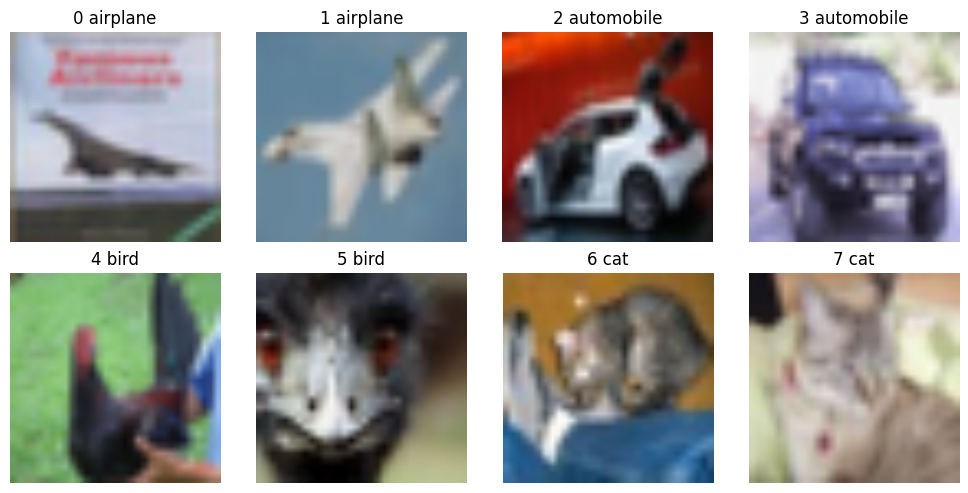

In [37]:


import os
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Set device (ensure this is defined in your environment)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "./data"
cifar_folder = os.path.join(data_dir, "cifar-10-batches-py")
download = not os.path.exists(cifar_folder)

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet18 expects 224x224 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]),  # Standard normalization
])

# Load dataset without shuffling to maintain order
dataset = datasets.CIFAR10(root=data_dir, train=False, download=download, transform=transform)
classes = dataset.classes  # List of class names in order

# Choose first 4 classes to get a total of 8 samples (2 per class)
desired_classes = classes[:4]  
samples_per_class = {cls: [] for cls in desired_classes}

# Iterate through dataset to collect 2 samples per desired class (non-random)
for img, label in dataset:
    class_name = classes[label]
    if class_name in desired_classes and len(samples_per_class[class_name]) < 2:
        samples_per_class[class_name].append((img, label))
    # Stop when 2 samples for each desired class are collected
    if all(len(samples) == 2 for samples in samples_per_class.values()):
        break

# Combine the samples in order (2 samples per class in the order of desired_classes)
ordered_samples = []
ordered_labels = []
ordered_class_names = []
for cls in desired_classes:
    for img, label in samples_per_class[cls]:
        ordered_samples.append(img)
        ordered_labels.append(label)
        ordered_class_names.append(cls)

# Create sample_input and sample_labels exactly as specified and load them to device
sample_input = torch.stack(ordered_samples).to(device)
sample_labels = torch.tensor(ordered_labels).to(device)

# Display the images with their class names
plt.figure(figsize=(10, 5))
for i, (img, cls_name) in enumerate(zip(ordered_samples, ordered_class_names)):
    # Convert tensor (C x H x W) to numpy array (H x W x C)
    npimg = img.cpu().permute(1, 2, 0).numpy()
    # Inverse normalization for visualization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    npimg = std * npimg + mean
    npimg = np.clip(npimg, 0, 1)
    plt.subplot(2, 4, i+1)
    plt.imshow(npimg)
    plt.title(str(i)+' '+cls_name)
    plt.axis('off')
plt.tight_layout()
plt.show()




# activations

In [37]:
# Sample input batch
# sample_input = torch.randn(8, 3, 224, 224).to(device)  # batch of 8 images

# Extract activations from a chosen layer (e.g., 'layer4')
layer4_activations = get_activation(resnet18, 'layer4', sample_input)
print("layer4 activations shape:", layer4_activations.shape)


# Compute and display the activation similarity matrix
activation_similarity = compute_activation_similarity(layer4_activations)
print("Activation similarity matrix shape:", activation_similarity.shape)




layer4 activations shape: torch.Size([8, 512, 7, 7])
Activation similarity matrix shape: torch.Size([8, 8])


# V1 ENTK

In [35]:




import torch
import torch.nn as nn

def compute_empirical_ntk(
    model: torch.nn.Module,
    inputs: torch.Tensor,
    labels: torch.Tensor,
    criterion: torch.nn.modules.loss._Loss
) -> torch.Tensor:
    """
    Computes the empirical NTK (Neural Tangent Kernel) matrix for a given batch of inputs.
    
    Args:
        model: The neural network model.
        inputs: A tensor of shape [batch_size, ...] containing the inputs.
        labels: A tensor of shape [batch_size, ...] containing the corresponding labels.
        criterion: The loss function (e.g., CrossEntropyLoss).
    
    Returns:
        ntk_matrix: A tensor of shape [batch_size, batch_size] representing the NTK.
    """
    model.train()
    batch_size = inputs.size(0)
    
    # Get all parameters that require gradients in a consistent order.
    parameters = [p for p in model.parameters() if p.requires_grad]
    n_params = sum(p.numel() for p in parameters)
    
    # Preallocate a Jacobian matrix of shape [batch_size, n_params]
    jacobian = torch.zeros(batch_size, n_params, device=inputs.device)
    
    for i in range(batch_size):
        model.zero_grad()
        x_i = inputs[i:i+1]  # Shape: [1, ...]
        y_i = labels[i:i+1]
        y_pred = model(x_i)
        loss = criterion(y_pred, y_i)
        loss.backward(retain_graph=True)
        
        idx = 0
        for param in parameters:
            if param.grad is None:
                raise RuntimeError(f"Gradient for parameter {param} is None.")
            grad_flat = param.grad.flatten()
            jacobian[i, idx:idx+grad_flat.numel()] = grad_flat
            idx += grad_flat.numel()
    
    ntk_matrix = jacobian @ jacobian.t()
    return ntk_matrix.detach()

# Example usage:
loss_fn = nn.CrossEntropyLoss()

# Compute NTK matrix using sample_input and sample_labels
ntk_matrix = compute_empirical_ntk(resnet18, sample_input, sample_labels, loss_fn)

print("NTK Matrix Shape:", ntk_matrix.shape)  # Should be (batch_size, batch_size)
display(ntk_matrix)

NTK Matrix Shape: torch.Size([8, 8])


tensor([[2154.4065,  716.2458, -202.2921,  348.3922,  -30.9304,   67.7090,
           -8.4311,  -25.9627],
        [ 716.2458, 1427.0865,   41.2836,   41.8891,    2.5517,  103.2295,
          -76.1662,  -90.3424],
        [-202.2921,   41.2836, 1585.6772,  340.5334,  -59.8105,   79.7090,
           17.7339, -124.7127],
        [ 348.3922,   41.8891,  340.5334, 1430.1554,   -7.1929,   13.9818,
          -24.0730,  -26.1386],
        [ -30.9304,    2.5517,  -59.8105,   -7.1929, 1371.7166,  385.9079,
          104.7683,   82.5762],
        [  67.7090,  103.2295,   79.7090,   13.9818,  385.9079, 1425.5596,
           80.7919, -162.6606],
        [  -8.4311,  -76.1662,   17.7339,  -24.0730,  104.7683,   80.7919,
         1831.0188,  445.5848],
        [ -25.9627,  -90.3424, -124.7127,  -26.1386,   82.5762, -162.6606,
          445.5848, 1428.5103]])

# SAE training

In [35]:
#NOTE You might want to experiment with different choices for the nonlinearity or normalization to  
#see how they affect the downstream correlations.


from tqdm.auto import trange, tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# --- Sparse Autoencoder Module ---
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, l1_lambda: float = 1e-6):
        """
        Args:
            input_dim: Dimension of the flattened input (e.g., 256*14*14).
            hidden_dim: Dimension of the latent space.
            l1_lambda: Coefficient for L1 sparsity penalty.
        """
        super(SparseAutoencoder, self).__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.l1_lambda = l1_lambda
        
    def forward(self, x):
        # Use Leaky ReLU to avoid zeroing out negative activations entirely.
        latent = F.leaky_relu(self.encoder(x), negative_slope=0.01)
        reconstruction = self.decoder(latent)
        return latent, reconstruction
    
    def loss(self, x, reconstruction, latent):
        # Reconstruction loss (MSE)
        mse_loss = F.mse_loss(reconstruction, x)
        # L1 loss on the latent activations for sparsity
        l1_loss = torch.mean(torch.abs(latent))
        return mse_loss + self.l1_lambda * l1_loss

# --- Training Function ---
def train_sae(sae: SparseAutoencoder, activations: torch.Tensor, epochs: int = 10, batch_size: int = 4, lr: float = 1e-3):
    """
    Trains the sparse autoencoder on the given activations.
    
    Args:
        sae: The SparseAutoencoder model.
        activations: Tensor of shape [num_samples, channels, height, width].
        epochs: Number of training epochs.
        batch_size: Batch size for training.
        lr: Learning rate.
        
    Returns:
        The trained SAE model.
    """
    sae.train()
    optimizer = optim.Adam(sae.parameters(), lr=lr)
    
    num_samples = activations.size(0)
    # Flatten activations: shape [num_samples, channels * height * width]
    activations_flat = activations.view(num_samples, -1)
    
    dataset = torch.utils.data.TensorDataset(activations_flat)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    print_every = 50  # Set N: print every N epochs
    
    for epoch in trange(epochs, desc="Training Epochs"):
        epoch_loss = 0.0
        latent_means = []
        for batch in dataloader:
            x_batch = batch[0]
            optimizer.zero_grad()
            latent, reconstruction = sae(x_batch)
            loss = sae.loss(x_batch, reconstruction, latent)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x_batch.size(0)
            latent_means.append(latent.mean().item())
        epoch_loss /= num_samples
        avg_latent = sum(latent_means) / len(latent_means)
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.6f}, Avg Latent: {avg_latent:.6f}")
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.6f}, Avg Latent: {avg_latent:.6f}")

    
    return sae



# --- SAE Correlation Computation ---
def compute_sae_correlation(sae: SparseAutoencoder, activations: torch.Tensor) -> torch.Tensor:
    """
    Computes a correlation matrix from SAE latent representations.
    
    Args:
        sae: Trained SparseAutoencoder.
        activations: Input activations [num_samples, channels, height, width].
    
    Returns:
        correlation_matrix: Tensor of shape [num_samples, num_samples]
    """
    sae.eval()
    with torch.no_grad():
        num_samples = activations.size(0)
        activations_flat = activations.view(num_samples, -1)
        latent, _ = sae(activations_flat)
        correlation_matrix = torch.matmul(latent, latent.t())
    return correlation_matrix

# --- Main Experiment ---
# Assuming you already have layer4_activations from ResNet-18 with shape [batch_size, 256, 14, 14]
batch_size_val = layer4_activations.size(0)
input_dim = layer4_activations.size(1) * layer4_activations.size(2) * layer4_activations.size(3)
hidden_dim = 512  # Adjust if needed

# Instantiate and train the SAE using the best settings found (l1_lambda=1e-6, 10 epochs, batch_size=4)
sae_model = SparseAutoencoder(input_dim=input_dim, hidden_dim=hidden_dim, l1_lambda=1e-6).to(device)
trained_sae = train_sae(sae_model, layer4_activations, epochs=100, batch_size=4, lr=1e-3)

# Compute the SAE correlation matrix (this variable is used in downstream plots)
sae_corr_matrix = compute_sae_correlation(trained_sae, layer4_activations)
print("SAE Correlation Matrix Shape:", sae_corr_matrix.shape)
display(sae_corr_matrix)

Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 50/100 - Loss: 0.136355, Avg Latent: -1.565133
Epoch 100/100 - Loss: 0.000010, Avg Latent: -1.625921
Epoch 100/100 - Loss: 0.000010, Avg Latent: -1.625921
SAE Correlation Matrix Shape: torch.Size([8, 8])


tensor([[1505.2170, 1196.1772, 1355.1959, 1355.2253, 1466.4385, 1465.0406,
         1449.5183, 1219.4280],
        [1196.1772, 1445.8574, 1288.6809, 1271.3601, 1360.0524, 1374.0779,
         1373.2463, 1132.0571],
        [1355.1959, 1288.6809, 1695.2463, 1438.9309, 1568.8496, 1565.2834,
         1543.9709, 1306.7195],
        [1355.2253, 1271.3601, 1438.9309, 1681.9897, 1545.1866, 1548.7668,
         1527.7795, 1273.6306],
        [1466.4385, 1360.0524, 1568.8496, 1545.1866, 2056.6650, 1686.9382,
         1662.3722, 1405.0349],
        [1465.0406, 1374.0779, 1565.2834, 1548.7668, 1686.9382, 2082.4421,
         1671.8094, 1413.8823],
        [1449.5183, 1373.2463, 1543.9709, 1527.7795, 1662.3722, 1671.8094,
         1920.5392, 1396.5090],
        [1219.4280, 1132.0571, 1306.7195, 1273.6306, 1405.0349, 1413.8823,
         1396.5090, 1486.6125]])

# visualize

Activation Similarity Matrix:


tensor([[1.0000, 0.3118, 0.3033, 0.3462, 0.3140, 0.3059, 0.3003, 0.2863],
        [0.3118, 1.0000, 0.3554, 0.3110, 0.2796, 0.3047, 0.3315, 0.2482],
        [0.3033, 0.3554, 1.0000, 0.3362, 0.3386, 0.3176, 0.3212, 0.2982],
        [0.3462, 0.3110, 0.3362, 1.0000, 0.3231, 0.2967, 0.3286, 0.2473],
        [0.3140, 0.2796, 0.3386, 0.3231, 1.0000, 0.2835, 0.3240, 0.2925],
        [0.3059, 0.3047, 0.3176, 0.2967, 0.2835, 1.0000, 0.3073, 0.2903],
        [0.3003, 0.3315, 0.3212, 0.3286, 0.3240, 0.3073, 1.0000, 0.2994],
        [0.2863, 0.2482, 0.2982, 0.2473, 0.2925, 0.2903, 0.2994, 1.0000]])

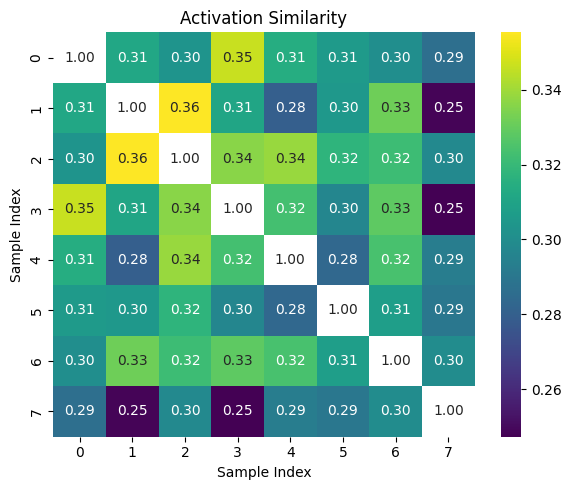

NTK Matrix:


tensor([[ 1.0000,  0.4085, -0.1094,  0.1985, -0.0180,  0.0386, -0.0042, -0.0148],
        [ 0.4085,  1.0000,  0.0274,  0.0293,  0.0018,  0.0724, -0.0471, -0.0633],
        [-0.1094,  0.0274,  1.0000,  0.2261, -0.0406,  0.0530,  0.0104, -0.0829],
        [ 0.1985,  0.0293,  0.2261,  1.0000, -0.0051,  0.0098, -0.0149, -0.0183],
        [-0.0180,  0.0018, -0.0406, -0.0051,  1.0000,  0.2760,  0.0661,  0.0590],
        [ 0.0386,  0.0724,  0.0530,  0.0098,  0.2760,  1.0000,  0.0500, -0.1140],
        [-0.0042, -0.0471,  0.0104, -0.0149,  0.0661,  0.0500,  1.0000,  0.2755],
        [-0.0148, -0.0633, -0.0829, -0.0183,  0.0590, -0.1140,  0.2755,  1.0000]])

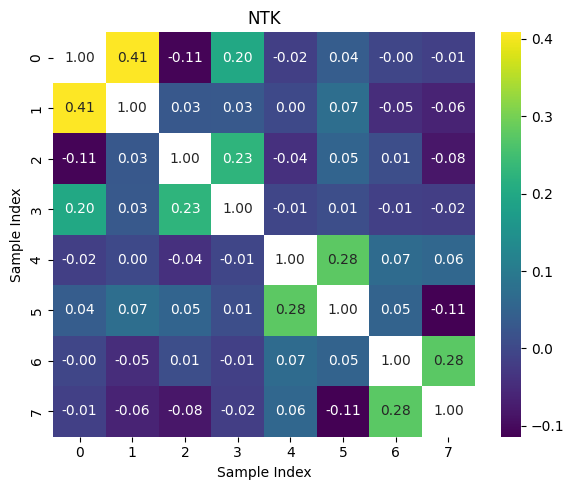

SAE Correlation Matrix:


tensor([[1.0000, 0.8108, 0.8484, 0.8517, 0.8335, 0.8275, 0.8525, 0.8152],
        [0.8108, 1.0000, 0.8231, 0.8153, 0.7887, 0.7919, 0.8241, 0.7722],
        [0.8484, 0.8231, 1.0000, 0.8521, 0.8402, 0.8331, 0.8557, 0.8231],
        [0.8517, 0.8153, 0.8521, 1.0000, 0.8308, 0.8275, 0.8500, 0.8054],
        [0.8335, 0.7887, 0.8402, 0.8308, 1.0000, 0.8151, 0.8364, 0.8035],
        [0.8275, 0.7919, 0.8331, 0.8275, 0.8151, 1.0000, 0.8360, 0.8036],
        [0.8525, 0.8241, 0.8557, 0.8500, 0.8364, 0.8360, 1.0000, 0.8265],
        [0.8152, 0.7722, 0.8231, 0.8054, 0.8035, 0.8036, 0.8265, 1.0000]])

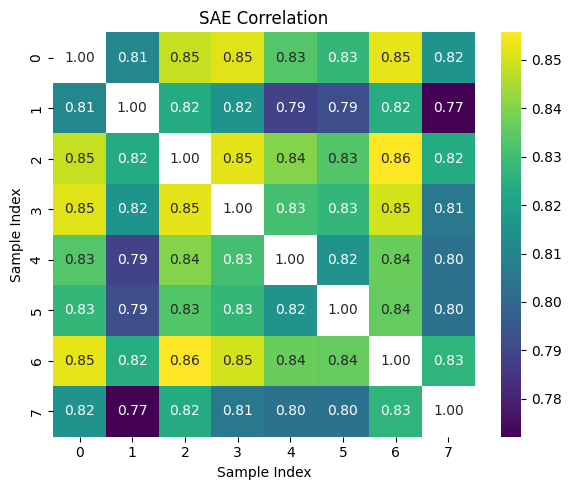

Activation Similarity Matrix:


tensor([[56676.7188, 18134.1914, 17863.7637, 21150.1602, 20872.1387, 20616.5176,
         18870.0215, 16630.5332],
        [18134.1914, 59693.5781, 21481.9824, 19496.0137, 19070.5723, 21075.5840,
         21382.2617, 14794.8193],
        [17863.7637, 21481.9824, 61215.4609, 21344.3086, 23391.7441, 22243.4922,
         20980.1172, 18001.4648],
        [21150.1602, 19496.0137, 21344.3086, 65843.2031, 23146.6836, 21551.9961,
         22258.0410, 15482.3936],
        [20872.1387, 19070.5723, 23391.7441, 23146.6836, 77958.3438, 22410.9199,
         23880.6465, 19926.8730],
        [20616.5176, 21075.5840, 22243.4922, 21551.9961, 22410.9199, 80135.9062,
         22965.5742, 20051.8887],
        [18870.0215, 21382.2617, 20980.1172, 22258.0410, 23880.6465, 22965.5742,
         69676.5938, 19282.6211],
        [16630.5332, 14794.8193, 18001.4648, 15482.3936, 19926.8730, 20051.8887,
         19282.6211, 59544.5234]])

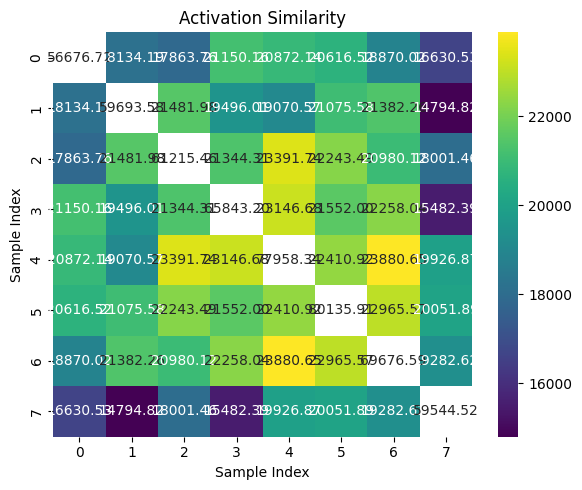

NTK Matrix:


tensor([[2154.4065,  716.2458, -202.2921,  348.3922,  -30.9304,   67.7090,
           -8.4311,  -25.9627],
        [ 716.2458, 1427.0865,   41.2836,   41.8891,    2.5517,  103.2295,
          -76.1662,  -90.3424],
        [-202.2921,   41.2836, 1585.6772,  340.5334,  -59.8105,   79.7090,
           17.7339, -124.7127],
        [ 348.3922,   41.8891,  340.5334, 1430.1554,   -7.1929,   13.9818,
          -24.0730,  -26.1386],
        [ -30.9304,    2.5517,  -59.8105,   -7.1929, 1371.7166,  385.9079,
          104.7683,   82.5762],
        [  67.7090,  103.2295,   79.7090,   13.9818,  385.9079, 1425.5596,
           80.7919, -162.6606],
        [  -8.4311,  -76.1662,   17.7339,  -24.0730,  104.7683,   80.7919,
         1831.0188,  445.5848],
        [ -25.9627,  -90.3424, -124.7127,  -26.1386,   82.5762, -162.6606,
          445.5848, 1428.5103]])

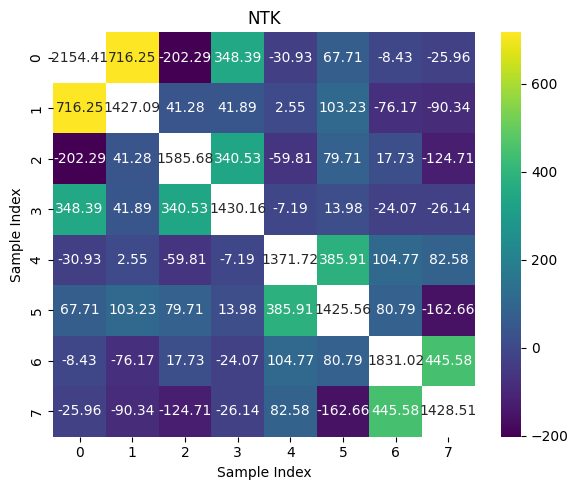

SAE Correlation Matrix:


tensor([[1505.2170, 1196.1772, 1355.1959, 1355.2253, 1466.4385, 1465.0406,
         1449.5183, 1219.4280],
        [1196.1772, 1445.8574, 1288.6809, 1271.3601, 1360.0524, 1374.0779,
         1373.2463, 1132.0571],
        [1355.1959, 1288.6809, 1695.2463, 1438.9309, 1568.8496, 1565.2834,
         1543.9709, 1306.7195],
        [1355.2253, 1271.3601, 1438.9309, 1681.9897, 1545.1866, 1548.7668,
         1527.7795, 1273.6306],
        [1466.4385, 1360.0524, 1568.8496, 1545.1866, 2056.6650, 1686.9382,
         1662.3722, 1405.0349],
        [1465.0406, 1374.0779, 1565.2834, 1548.7668, 1686.9382, 2082.4421,
         1671.8094, 1413.8823],
        [1449.5183, 1373.2463, 1543.9709, 1527.7795, 1662.3722, 1671.8094,
         1920.5392, 1396.5090],
        [1219.4280, 1132.0571, 1306.7195, 1273.6306, 1405.0349, 1413.8823,
         1396.5090, 1486.6125]])

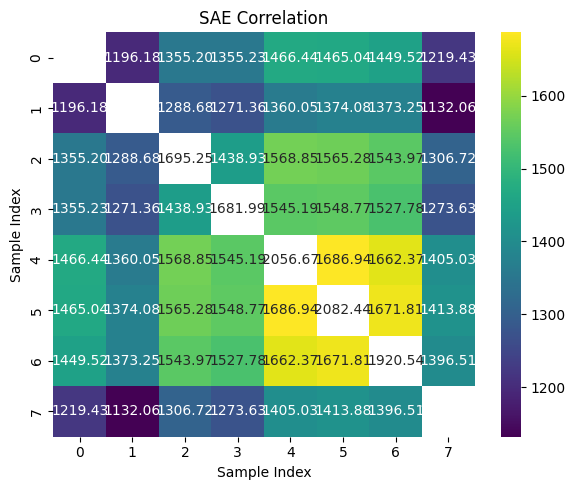

In [36]:

# # # import torch
# # # import matplotlib.pyplot as plt
# # # import seaborn as sns

# # # def normalize_matrix(M: torch.Tensor) -> torch.Tensor:
# # #     """
# # #     Normalizes a similarity matrix using diagonal normalization (cosine similarity).
    
# # #     Args:
# # #         M: Input matrix of shape [n, n].
        
# # #     Returns:
# # #         Normalized matrix of shape [n, n] with diagonal elements equal to 1.
# # #     """
# # #     diag = torch.sqrt(torch.diag(M))
# # #     norm_matrix = M / (diag.unsqueeze(1) * diag.unsqueeze(0) + 1e-8)
# # #     return norm_matrix

# # # def plot_heatmap(matrix: torch.Tensor, title: str, figsize: tuple=(6,5), cmap: str="viridis"):
# # #     plt.figure(figsize=figsize)
# # #     sns.heatmap(matrix.cpu().numpy(), annot=True, fmt=".2f", cmap=cmap)
# # #     plt.title(title)
# # #     plt.xlabel("Sample Index")
# # #     plt.ylabel("Sample Index")
# # #     plt.tight_layout()
# # #     plt.show()

# # # # Assume activation_similarity, ntk_matrix, and sae_corr_matrix have been computed as before.
# # # norm_activation_similarity = normalize_matrix(activation_similarity)
# # # norm_ntk_matrix = normalize_matrix(ntk_matrix)
# # # norm_sae_corr_matrix = normalize_matrix(sae_corr_matrix)

# # # print("Normalized Activation Similarity Matrix:")
# # # display(norm_activation_similarity)
# # # plot_heatmap(norm_activation_similarity, "Normalized Activation Similarity")

# # # print("Normalized NTK Matrix:")
# # # display(norm_ntk_matrix)
# # # plot_heatmap(norm_ntk_matrix, "Normalized NTK")

# # # print("Normalized SAE Correlation Matrix:")
# # # display(norm_sae_corr_matrix)
# # # plot_heatmap(norm_sae_corr_matrix, "Normalized SAE Correlation")




# # import torch
# # import matplotlib.pyplot as plt
# # import seaborn as sns

# # def normalize_matrix(M: torch.Tensor) -> torch.Tensor:
# #     """
# #     Normalizes a similarity matrix using diagonal normalization (cosine similarity).
    
# #     Args:
# #         M: Input matrix of shape [n, n].
        
# #     Returns:
# #         Normalized matrix of shape [n, n] with diagonal elements equal to 1.
# #     """
# #     diag = torch.sqrt(torch.diag(M))
# #     norm_matrix = M / (diag.unsqueeze(1) * diag.unsqueeze(0) + 1e-8)
# #     return norm_matrix

# # def plot_heatmap(matrix: torch.Tensor, title: str, figsize: tuple=(6,5), cmap: str="viridis"):
# #     plt.figure(figsize=figsize)
# #     # Force the colorbar limits to be from 0 to 1
# #     sns.heatmap(matrix.cpu().numpy(), annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1)
# #     plt.title(title)
# #     plt.xlabel("Sample Index")
# #     plt.ylabel("Sample Index")
# #     plt.tight_layout()
# #     plt.show()

# # # Assume activation_similarity, ntk_matrix, and sae_corr_matrix have been computed as before.
# # norm_activation_similarity = normalize_matrix(activation_similarity)
# # norm_ntk_matrix = normalize_matrix(ntk_matrix)
# # norm_sae_corr_matrix = normalize_matrix(sae_corr_matrix)

# # print("Normalized Activation Similarity Matrix:")
# # display(norm_activation_similarity)
# # plot_heatmap(norm_activation_similarity, "Normalized Activation Similarity")

# # print("Normalized NTK Matrix:")
# # display(norm_ntk_matrix)
# # plot_heatmap(norm_ntk_matrix, "Normalized NTK")

# # print("Normalized SAE Correlation Matrix:")
# # display(norm_sae_corr_matrix)
# # plot_heatmap(norm_sae_corr_matrix, "Normalized SAE Correlation")



# import torch
# import matplotlib.pyplot as plt
# import seaborn as sns

# def normalize_matrix(M: torch.Tensor) -> torch.Tensor:
#     """
#     Normalizes a similarity matrix using diagonal normalization (cosine similarity).
    
#     Args:
#         M: Input matrix of shape [n, n].
        
#     Returns:
#         Normalized matrix of shape [n, n] with diagonal elements equal to 1.
#     """
#     diag = torch.sqrt(torch.diag(M))
#     norm_matrix = M / (diag.unsqueeze(1) * diag.unsqueeze(0) + 1e-8)
#     return norm_matrix

# def plot_heatmap(matrix: torch.Tensor, title: str, figsize: tuple = (6, 5), cmap: str = "viridis"):
#     plt.figure(figsize=figsize)
#     # Force the colorbar limits to be from 0 to 1
#     sns.heatmap(matrix.cpu().numpy(), annot=True, fmt=".2f", cmap=cmap)#, vmin=0, vmax=1)
#     plt.title(title)
#     plt.xlabel("Sample Index")
#     plt.ylabel("Sample Index")
#     plt.tight_layout()
#     plt.show()

# def run_similarity_analysis(activation_similarity: torch.Tensor, 
#                             ntk_matrix: torch.Tensor, 
#                             sae_corr_matrix: torch.Tensor,
#                             normalize: bool = True):
#     """
#     Wrapper function to process and display similarity matrices.
    
#     Args:
#         activation_similarity: Similarity matrix for activations.
#         ntk_matrix: Neural tangent kernel matrix.
#         sae_corr_matrix: SAE correlation matrix.
#         normalize: If True, apply normalization to matrices.
#     """
#     if normalize:
#         act_sim = normalize_matrix(activation_similarity)
#         ntk = normalize_matrix(ntk_matrix)
#         sae = normalize_matrix(sae_corr_matrix)
#     else:
#         act_sim = activation_similarity
#         ntk = ntk_matrix
#         sae = sae_corr_matrix

#     print("Activation Similarity Matrix:")
#     display(act_sim)
#     plot_heatmap(act_sim, "Activation Similarity")
    
#     print("NTK Matrix:")
#     display(ntk)
#     plot_heatmap(ntk, "NTK")
    
#     print("SAE Correlation Matrix:")
#     display(sae)
#     plot_heatmap(sae, "SAE Correlation")



# run_similarity_analysis(activation_similarity,
#                             ntk_matrix,
#                             sae_corr_matrix,
#                             normalize=True)



# run_similarity_analysis(activation_similarity,
#                             ntk_matrix,
#                             sae_corr_matrix,
#                             normalize=False)



import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def normalize_matrix(M: torch.Tensor) -> torch.Tensor:
    """
    Normalizes a similarity matrix using diagonal normalization (cosine similarity).
    
    Args:
        M: Input matrix of shape [n, n].
        
    Returns:
        Normalized matrix of shape [n, n] with diagonal elements equal to 1.
    """
    diag = torch.sqrt(torch.diag(M))
    norm_matrix = M / (diag.unsqueeze(1) * diag.unsqueeze(0) + 1e-8)
    return norm_matrix

def plot_heatmap(matrix: torch.Tensor, title: str, figsize: tuple = (6, 5), cmap: str = "viridis", custom_diag: bool = False):
    """
    Plots a heatmap of the given matrix.
    
    If custom_diag is True:
      - The color range is determined only by the off-diagonal values.
      - Diagonal cells are overlaid in white.
    
    Args:
        matrix: The input matrix (torch.Tensor).
        title: Title of the plot.
        figsize: Figure size.
        cmap: Colormap.
        custom_diag: Toggle to enable the special handling of the diagonal.
    """
    plt.figure(figsize=figsize)
    matrix_np = matrix.cpu().numpy()

    if custom_diag:
        # Get off-diagonal values for setting vmin and vmax.
        mask_off_diag = ~np.eye(matrix_np.shape[0], dtype=bool)
        off_diag_vals = matrix_np[mask_off_diag]
        vmin, vmax = off_diag_vals.min(), off_diag_vals.max()
    else:
        vmin, vmax = None, None

    ax = sns.heatmap(matrix_np, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("Sample Index")
    
    if custom_diag:
        # Overlay white boxes on the diagonal.
        for i in range(matrix_np.shape[0]):
            ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color="white", lw=0))
    
    plt.tight_layout()
    plt.show()

def run_similarity_analysis(activation_similarity: torch.Tensor, 
                            ntk_matrix: torch.Tensor, 
                            sae_corr_matrix: torch.Tensor,
                            normalize: bool = True,
                            custom_diag: bool = False):
    """
    Processes and displays similarity matrices.
    
    Args:
        activation_similarity: Similarity matrix for activations.
        ntk_matrix: Neural tangent kernel matrix.
        sae_corr_matrix: SAE correlation matrix.
        normalize: If True, apply normalization to matrices.
        custom_diag: If True, limits the colorbar to off-diagonal correlations and overlays the diagonal in white.
    """
    if normalize:
        act_sim = normalize_matrix(activation_similarity)
        ntk = normalize_matrix(ntk_matrix)
        sae = normalize_matrix(sae_corr_matrix)
    else:
        act_sim = activation_similarity
        ntk = ntk_matrix
        sae = sae_corr_matrix

    print("Activation Similarity Matrix:")
    display(act_sim)
    plot_heatmap(act_sim, "Activation Similarity", custom_diag=custom_diag)
    
    print("NTK Matrix:")
    display(ntk)
    plot_heatmap(ntk, "NTK", custom_diag=custom_diag)
    
    print("SAE Correlation Matrix:")
    display(sae)
    plot_heatmap(sae, "SAE Correlation", custom_diag=custom_diag)


# Example usage:
run_similarity_analysis(activation_similarity,
                        ntk_matrix,
                        sae_corr_matrix,
                        normalize=True,
                        custom_diag=True)

run_similarity_analysis(activation_similarity,
                        ntk_matrix,
                        sae_corr_matrix,
                        normalize=False,
                        custom_diag=True)


